In [2]:
import pandas as pd
import pickle as pickle
import numpy as np
import string 

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import matplotlib.lines as mlines

from utils.utils import GENDER, CTRY, COLOR
from utils.utils import set_mpl_style

In [3]:
## Set mpl Style
set_mpl_style()
cm_to_inch = 1/2.54
fs = 7

In [ ]:
## OPEN RESULTS:
input_fig_path = ''
output_fig_path = ''

n_iterations = 1000

# Open Palindromes results
fname = f"dic_palind_BS{n_iterations}.pkl"
dic_palind = pd.read_pickle(input_fig_path + fname)
print('>> dic_palind')
display(dic_palind)

# Open Tours length results
fname = f"frac_tours_length.pkl"
dic_tours_length = pd.read_pickle(input_fig_path + fname)
print('>> dic_tours_length')
display(dic_tours_length)

# Open Gender Gap Tours length results
fname = f"gendergap_tours_length_pooled_activity_BS{n_iterations}.pkl"
dic_gg_tours = pd.read_pickle(input_fig_path + fname)
print('>> dic_gg_tours pooled across countries and activities')
display(dic_gg_tours['all'])

# Open Gender Gap Tours length results by distance bins
fname = f"gendergap_tours_length_by_dist_pooled_BS{n_iterations}_cap300.pkl"
dic_gg_tours_distance = pd.read_pickle(input_fig_path + fname)
print('>> dic_gg_tours_distance pooled across countries and activities')
display(dic_gg_tours_distance['all'])

In [7]:
## Define plot variables
TEST = ["all", "inactive", "moderate", "active" ]
dTEST = {"inactive": "inactive (1st–3rd deciles)", "moderate": "moderate (4th–7th)", "active": "active (8th–10th)", "all": "all data"}

dTESTmarker = {
    "inactive": "v",
    "moderate": "d",
    "active": "^",    
    'all': "o",
}
dTESTsize = {
    "inactive": 2,
    "moderate": 2,
    "active": 2,
    'all': 10,
}

LENG_LABELS = [ '3\nABA', '4\nABCA', '5\nABCDA', '6']  + ['7-10', '11-20', '20+']
dLENG = {
    '3\nABA': 'Back-and-forth',
    '4\nABCA': '2-stop',
    '5\nABCDA': '3-stop',
    '6': '4-stop',
    '7-10': '7–10-stop',
    '11-20': '11–20-stop',
    '20+': '>20-stop'
}

In [8]:
## Define plot parameters
background = True
alpha_bck = 0.25

Global x-limits: -0.03, 0.03 (xminmax: 0.03)


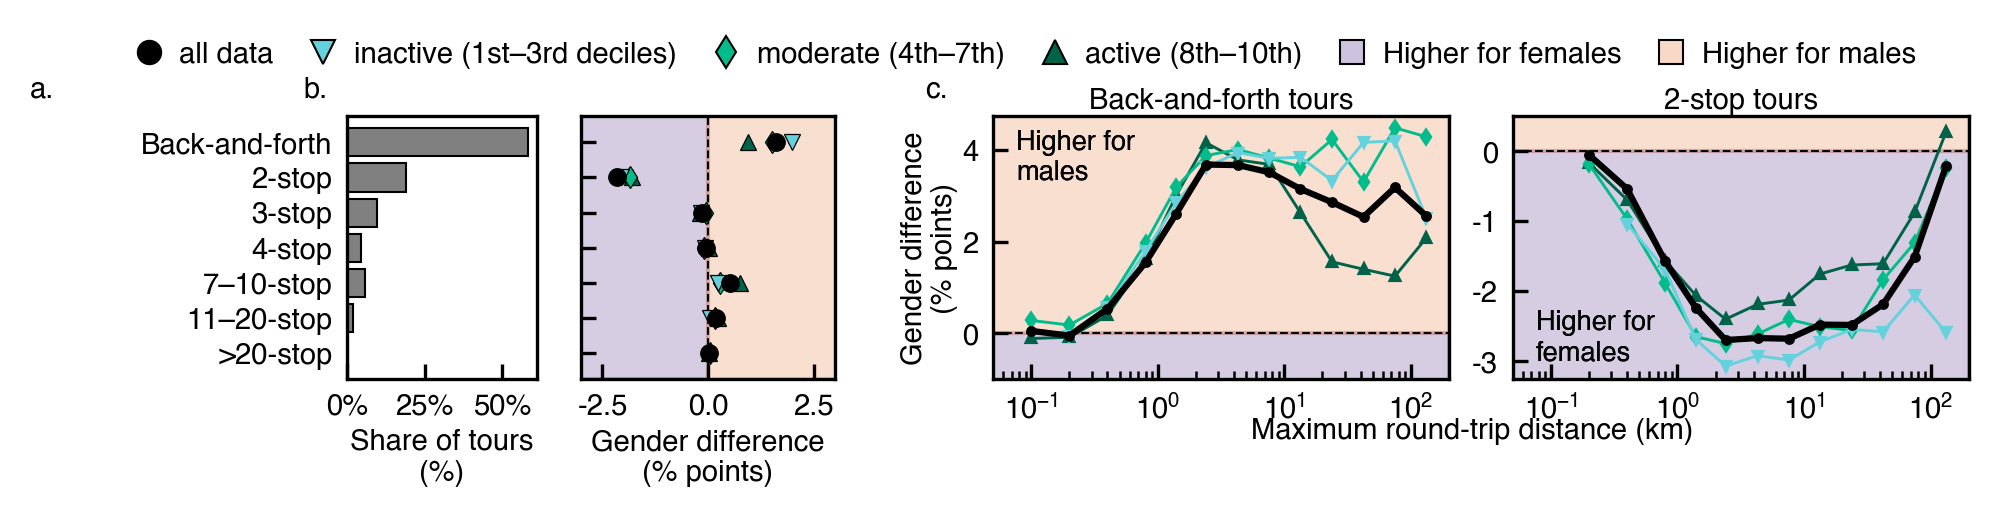

In [ ]:
## PANEL FOR FIGURE -  1 ROW EXERCISE
fig = plt.figure(figsize=(18.3 * cm_to_inch, 4* cm_to_inch))

gs = fig.add_gridspec(2, 1,  height_ratios= [1,20], hspace=0.4)

# -- Legend row
ax_leg = fig.add_subplot(gs[0, :])  
for spine in ax_leg.spines.values():
    spine.set_visible(False)
ax_leg.set_xticks([])
ax_leg.set_yticks([])

# -- Journeys row
jrnys_gs = gs[1, :].subgridspec(1, 3, wspace=0.3, width_ratios=[0.5, 2, 4])
ax_jrny = fig.add_subplot(jrnys_gs[0, 0])  

# Split panel hporizontally into 2 columns
jlen_gs = jrnys_gs[0, 1].subgridspec(1, 2, hspace=0.01, width_ratios=[1.5,2])
ax_frac = fig.add_subplot(jlen_gs[0, 0])   
ax_jlen = fig.add_subplot(jlen_gs[0, 1], sharey=ax_frac)

# Split the last panel vertically into 2 rows
dist_gs = jrnys_gs[0, 2].subgridspec(1, 2, wspace=0.14)
ax_bnf    = fig.add_subplot(dist_gs[0, 0])
ax_2sj = fig.add_subplot(dist_gs[0, 1])


# Collect all axes in the order you want them labeled
axes = [
    ax_jrny, ax_frac, ax_bnf,
]

# Loop and assign labels
for i, ax in enumerate(axes):
    ax.text(
        -0.1, 1.05, f"{string.ascii_lowercase[i]}.",  # "a.", "b.", "c."...
        transform=ax.transAxes,
        va="bottom", ha="right"
    )

## -- A. INSERT JOURNEY FIGURE ----------------------------
for spine in ax_jrny.spines.values():
    spine.set_visible(False)
ax_jrny.set_xticks([])
ax_jrny.set_yticks([])


## -- B.left FRACT USERS JRNY LENGTH --------------------------
df_frac = dic_tours_length.sort_values(by='leng_bin', ascending=False)
ax_frac.barh(
    df_frac["leng_desc"], 
    df_frac["frac"], 
    color="grey", edgecolor="k", lw=0.5
)
ax_frac.tick_params(axis='y', length=0)  
ax_frac.set_xlabel("Share of tours\n(%)", labelpad=1)
ax_frac.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=3))
ax_frac.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))


## -- B.right GENDER GAP BY JRNY LENGTH ------------------------
for test in TEST[::-1]:
    df_g = dic_gg_tours[test]

    df_g["leng_bin"] = pd.Categorical(df_g["leng_bin"], categories=LENG_LABELS, ordered=True)
    df_g = df_g.sort_values(by='leng_bin', ascending=False)

    ## PLOT RESULTS 
    margin = 0.05 if test == 'all' else 0.01 if test == 'ae80' else -0.01 if test == 'ie30' else 0.05

    ypos_map = {lab: i for i, lab in enumerate(LENG_LABELS[::-1])}
    y_base = df_g["leng_bin"].map(ypos_map).astype(float)
    margins = {'ie30': -0.2, 'mid3080': -0.1, 'all': 0.1, 'ae80': 0.2, }
    margin = margins.get(test, 0)
    y = y_base #+ margin

    ax_jlen.errorbar(df_g['mean_gap'], y, 
                xerr=df_g['se_gap'], fmt=dTESTmarker[test], lw=1,
                markersize= 3.8 if test !='all' else 4.2, color=COLOR[test], alpha=1, 
                markeredgecolor='black', markeredgewidth=0.3, 
                label=dTEST[test], zorder=10) #

    ax_jlen.set_yticks(range(len(LENG_LABELS[::-1])))
    ax_jlen.set_yticklabels([dLENG[lab] for lab in LENG_LABELS[::-1]], fontsize=fs)
    
    ax_jlen.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x*100:.1f}"))
    ax_jlen.set_xlabel('Gender difference\n(% points)', labelpad=2)


# Collect global limits (now on x-axis)
all_xlims = [ax_jlen.get_xlim()]  # if looping over multiple axes, collect all
margin = 0.005
global_xmin = round(min([xlim[0] for xlim in all_xlims]) - margin, 2)
global_xmax = round(max([xlim[1] for xlim in all_xlims]) + margin, 2)
global_xminmax = max(np.abs(global_xmin), np.abs(global_xmax))
# print(f"Global x-limits: {global_xmin}, {global_xmax} (xminmax: {global_xminmax})")

# Apply background colors horizontally (now x spans)
ax_jlen.axvline(0, color='black', linestyle='--', linewidth=0.5)
if background:
    ax_jlen.axvspan(-global_xminmax, 0, ymin=0, ymax=1.05, color=COLOR["FEMALE"], alpha=alpha_bck)
    ax_jlen.axvspan(0, global_xminmax*2, ymin=0, ymax=1.05, color=COLOR["MALE"], alpha=alpha_bck)

else:
    ax_jlen.text(0, 1, 'Higher for\nfemales', transform=ax_jlen.transAxes, ha='left', va='bottom', fontsize=fs-0.5)
    ax_jlen.text(1, 1, 'Higher for\nmales', transform=ax_jlen.transAxes, ha='right', va='bottom',  fontsize=fs-0.5)

ax_jlen.set_xlim(-global_xminmax, global_xminmax)
plt.setp(ax_jlen.get_yticklabels(), visible=False)


## -- C. GENDER GAP BY JRNY DIST [BnF, 2sJ] ---------------
xmin = 0.05
xmax = 200
for ax, leng_bin in zip([ax_bnf, ax_2sj], ['3\nABA', '4\nABCA']):
    for test in TEST[::-1]:    
        df_g = dic_gg_tours_distance[test]
        df_cg = df_g[df_g['leng_bin'] == leng_bin].dropna(subset=['mean_frac_mean']).sort_values(by='dist_xbins_med')

        # Cap to XMAX:
        df_cg['dist_xbins_med'] = df_cg['dist_xbins_med'].astype(float)
        df_cg = df_cg[df_cg['dist_xbins_med'] <= xmax]
        ax.errorbar(x = df_cg["dist_xbins_med"], y = df_cg["mean_gap_mean"], yerr = df_cg['se_gap_pooled_se'],
            fmt=dTESTmarker[test],  
            markersize= 2 if test !='all' else 1.6,
            lw= 1.5 if test == 'all' else 0.7, 
            ls = '-',
            color=COLOR[test], ) 
        ax.set_xscale('log')
        ax.set_title(dLENG[leng_bin] + ' tours', pad=2)
    

    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x*100:.0f}"))

    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5) 
    ymin = ax.get_ylim()[0]
    ymax = ax.get_ylim()[1]
    if ('4' in leng_bin) and (ymax < 0.005):
        ymax = 0.005
    if ('3' in leng_bin) and (ymin > -0.005):
        ymin = -0.01

    if background:
        ax.axhspan(ymin-10, 0, color=COLOR["FEMALE"], alpha=alpha_bck) 
        ax.axhspan(0, ymax+100, color=COLOR["MALE"], alpha=alpha_bck)  

    # else:
    ax_bnf.text(0.05, 0.95, 'Higher for\nmales', transform=ax_bnf.transAxes, ha='left', va='top', fontsize=fs-0.5)
    ax_2sj.text(0.05, 0.05, 'Higher for\nfemales', transform=ax_2sj.transAxes, ha='left', va='bottom',  fontsize=fs-0.5)

    ax.set_ylim(ymin, ymax)
    ax.set_xlim(xmin, xmax)

ax_bnf.set_ylabel('Gender difference\n(% points)', labelpad=1)
ax_bnf.text(1.05, -0.2, 'Maximum round-trip distance (km)', ha='center', va='center', transform=ax_bnf.transAxes)


## -- LEGEND ------------------------
empty_handle = mpl.lines.Line2D([], [], color='none', marker='s', markersize=4, linestyle='None', label="    "*4)
handles_test = [mpl.lines.Line2D([], [], color=COLOR[test], marker=dTESTmarker[test], markersize=4,
    markeredgecolor="black", markeredgewidth=0.5, linestyle='None', label=dTEST[test]) for test in TEST]
handle_background = [mpl.lines.Line2D([], [], markerfacecolor= mpl.colors.to_rgba(COLOR[gen], alpha=alpha_bck + 0.05), marker='s', markersize=4, linestyle='None',
    markeredgecolor='black', markeredgewidth=0.5, label="Higher for " + gen.lower() +'s') for gen in GENDER[::-1]]

handles = handles_test
if background:
    handles += handle_background 

leg = ax_leg.legend(
    handles=handles,
    loc='center',
    bbox_to_anchor=(0.5,0.5),
    frameon=False,
    ncol=len(handles),
    fontsize=fs,
    handletextpad=0.05,
    columnspacing=0.7, 
    markerscale = 1.4,
)

fig.align_xlabels(axes)

fig.subplots_adjust(left=0.04, right=0.92, top=0.96, bottom=0.26)
plt.savefig(output_fig_path + "fig_3_tours.pdf", bbox_inches=None)
plt.show() 

----

## SUPPLEMENTARY MATERIALS

In [ ]:
# Open Gender Gap Tours length results by coutnry
fname = f"gendergap_tours_length_byctry_activity_BS{n_iterations}.pkl"
dic_gg_tours_C = pd.read_pickle(input_fig_path + fname)
print('>> dic_gg_tours by countries and activities')
display(dic_gg_tours_C['all'])

# Open Gender Gap Tours length results by distance bins and country
fname = f"gendergap_tours_length_by_dist_byctry_BS{n_iterations}_cap300.pkl"
dic_gg_tours_distance_C = pd.read_pickle(input_fig_path + fname)
print('>> dic_gg_tours_distance by countries and activities')
display(dic_gg_tours_distance_C['all'])

# Open Gender Gap Tours length results by distance bins and country
fname = f"gendergap_tours_length_by_durat_byctry_BS{n_iterations}_cap{24 * 60 * 3}.pkl"
dic_gg_tours_durat_C = pd.read_pickle(input_fig_path + fname)
print('>> dic_gg_tours_duration pooled by countries and activities')
display(dic_gg_tours_durat_C['all'])

In [ ]:
## S10. Gender gap by tour lenght and country
fig, axs = plt.subplots(4,2,  figsize=(18.3 * cm_to_inch, 16 * cm_to_inch), sharey = True, sharex=True)

for ax,ctry in zip(axs.ravel(), CTRY[::-1]):
    ax.set_title(ctry, pad = -20)
    
    for test in TEST[::-1]:
        df_ = dic_gg_tours_C[test]
        df_c = df_[df_['GID_0'] == ctry]

        df_c["leng_bin"] = pd.Categorical(df_c["leng_bin"], categories=LENG_LABELS, ordered=True)
        df_c["leng_bin_lab"] = df_c["leng_bin"].apply(lambda x: dLENG[x])
        df_c = df_c.sort_values(by='leng_bin')

        ## PLOT RESULTS
        m = 'o' if test == 'all' else 's'
        lw = 1 if test == 'all' else 0.7
        ms = 4 #3.5 if test == 'all' else 3.5
        ax.errorbar(df_c['leng_bin_lab'], df_c['mean_gap'], yerr=df_c['se_gap'], fmt=dTESTmarker[test], lw=1,
                markersize=dTESTsize[test], color=COLOR[test], alpha=1, label=dTEST[test], zorder=10)


        ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
        
        # Force all bin ticks to be shown
        # ax.set_xticks(range(len(df_g['df_c['leng_bin_lab'])))  # tick positions
        ax.set_xticklabels(df_c['leng_bin_lab'], rotation=30, ha='center')  
        ax.tick_params(axis="x", pad=1)

all_ylims = [ax.get_ylim() for ax in axs.ravel()]
margin = 0.005
global_ymin = round(min([ylim[0] for ylim in all_ylims]) - margin,2)
global_ymax = round(max([ylim[1] for ylim in all_ylims]) + margin,2)
# print(global_ymin, global_ymax)

for ax in axs.ravel():
    # Apply background colors globally
    ax.axhspan(global_ymin, 0, xmin=0, xmax=1.05, color=COLOR["FEMALE"], alpha=0.3)  # Adjust range and color as needed
    ax.axhspan(0, global_ymax*2, xmin=0, xmax=1.05, color=COLOR["MALE"], alpha=0.3)  # Adjust range and color as needed
    ax.set_ylim(global_ymin, global_ymax)

# ax.set_ylim(-0.04, 0.04)
# # reduce the y-axis limits
# ax.set_yticks(np.arange(-0.04, 0.05, 0.02))  # Adjust the step size as needed
# ax.set_yticklabels([f"{round(i*100, 0)}%" for i in np.arange(-0.04, 0.05, 0.02)])  # Format the labels as percentages

# Lables
# fig.supxlabel('journey length', y=0.025)
fig.supylabel(r'$\Delta$ users (%M - %F)',x = 0.05)


# axs[0,1].legend(loc = 'lower right', frameon = False, ncol = 4, bbox_to_anchor = (1, 1.05),
#     handletextpad=0.05,
#     columnspacing=0.7, 
#     markerscale = 1.8,)
    #, ncol = 4)


## -- LEGEND ------------------------
empty_handle = mpl.lines.Line2D([], [], color='none', marker='s', markersize=4, linestyle='None', label="    "*8)

handles_activity = [mpl.lines.Line2D([], [], color=COLOR[test], marker=dTESTmarker[test],
     markersize=4, markeredgecolor="black", markeredgewidth=0.3,  linestyle='None', label=dTEST[test]) for test in TEST]

handle_background = [mpl.lines.Line2D([], [], markerfacecolor= mpl.colors.to_rgba(COLOR[gen], alpha=0.3), marker='s', markersize=4, linestyle='None', 
    markeredgecolor='black', markeredgewidth=0.5, label="Higher for " + gen.lower() +'s') for gen in GENDER[::-1]]

handles = handles_activity + handle_background

ncol = len(handles) # round(len(handles)/2)
leg = fig.legend(
    handles=handles,
    loc='lower center',
    bbox_to_anchor=(0.5,0.9),
    frameon=False,
    ncol=ncol,
    fontsize=fs-0.5,
    handletextpad=0.04,
    columnspacing=0.68, 
    markerscale=1.4,
)
leg._legend_title_box.sep = 20

fig.subplots_adjust(hspace=0.15, wspace=0.1) #left=0.04, right=0.92, top=0.96, bottom=0.26,
plt.savefig(output_fig_path + "si_tourlen_C.pdf", bbox_inches="tight") # 
plt.show()

In [ ]:
## S11. Plot Gender Gap Tours length results by distance bins by COUNTRY

dic_lendist_gap = dic_gg_tours_distance_C.copy()
xlabel = 'max reward (km)'
figsize = (4, 3)

sel_LENG_LABELS = ['3\nABA', '4\nABCA']
dLENG = {'3\nABA': 'Back-and-forth', '4\nABCA': '2-stop journey'}
xmin = 0.05
xmax = 200 #300 # [set when CAPPED]

for sel_LENG in sel_LENG_LABELS:


    fig = plt.figure(figsize=(18.3 * cm_to_inch, 9 * cm_to_inch), constrained_layout=False)

    # Outer grid: controls the BIG gap between the two LENG BIN AREAS 
    outer = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.3)  

    # Inner grids: control spacing *within* each 2×5 grid
    top_spec = outer[0].subgridspec(2, 5, wspace=0.1, hspace=0.3, height_ratios=[1, 3])    
    bot_spec = outer[1].subgridspec(2, 5, wspace=0.1, hspace=0.3, height_ratios=[1, 3])

    # Create axes arrays for each grid
    axs_3 = top_spec.subplots(sharex=True, sharey=False)
    axs_4 = bot_spec.subplots(sharex=True, sharey=False)

    axs_frac_all = axs_3[0,:], axs_4[0,:]
    axs_frac_all = np.ravel(axs_frac_all)

    axs_main_all = axs_3[1,:], axs_4[1,:]
    axs_main_all = np.ravel(axs_main_all)

    ## GET OVERAL FRACT OF VISITS PER KM BIN
    for ax_frac, ctry in zip(axs_frac_all, CTRY[::-1]):
        ax_frac.set_title(ctry, pad = 1)
        df_g = dic_lendist_gap['all']
        df_cg = df_g[(df_g['leng_bin'] == sel_LENG) & (df_g['GID_0'] == ctry)].dropna(subset=['mean_frac']).sort_values(by='dist_xbins_med')

        # Plot histogram in ax_frac
        ax_frac.plot(
            df_cg["dist_xbins_med"],
            df_cg["mean_frac"],
            color="grey",
            marker=".",
            markersize=0.5,
            linestyle="-",   # keeps the line
            lw=0.8   # thinner error bar lines
        ) 

        ax_frac.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
        ax_frac.set_xscale('log')
        # ax_frac.set_xlim(xmin, xmax)

    ## GET FRACT M-F PER DIST BIN FOR EACH TEST
    for ax, ctry in zip(axs_main_all, CTRY[::-1]):
        lw = 0.7 if test == 'all' else 0.5
        
        for test in TEST:
            df_g = dic_lendist_gap[test]
            df_cg = df_g[(df_g['leng_bin'] == sel_LENG) & (df_g['GID_0'] == ctry)].dropna(subset=['mean_frac']).sort_values(by='dist_xbins_med')

            # cap to XMAX:
            df_cg['dist_xbins_med'] = df_cg['dist_xbins_med'].astype(float)
            df_cg = df_cg[df_cg['dist_xbins_med'] <= xmax]
            # if test == 'all':
                # print(max(df_cg.dist_xbins_med))

            legend_ = False #True if i_col == len(sel_LENG_LABELS)-1 else False

            ax.errorbar(x = df_cg["dist_xbins_med"], y = df_cg["mean_gap"], yerr = df_cg['se_gap'],
                fmt=dTESTmarker[test],   markersize=dTESTsize[test]-2, lw=lw, ls = '-', color=COLOR[test], label = dTEST[test])
            ax.set_xscale('log')
        

        # Set Percent fomratter at y axis
        # ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))    
        ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x*100:.0f}"))

        # # Force all bin ticks to be shown
        # # ax.set_xticks(range(len(df_g)))  # tick positions
        # # ax.set_xticklabels(df_g['bin'], rotation=0)  # force display of all bin labels

        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5) 


    # Apply background colors globally
    ylims = [ax.get_ylim() for ax in axs_main_all]
    global_ymin = min(y[0] for y in ylims)
    global_ymax = max(y[1] for y in ylims) 

    for i, ax in enumerate(axs_main_all):
        ax.axhspan(global_ymin, 0, xmin=xmin-0.05, xmax=xmax, color=COLOR["FEMALE"], alpha=0.25)  # Adjust range and color as needed
        ax.axhspan(0, global_ymax, xmin=xmin-0.05, xmax=xmax, color=COLOR["MALE"], alpha=0.25)  # Adjust range and color as needed
        # print(global_ymin, global_ymax)
        if global_ymin < -0.10:
            global_ymin = -0.10
        if global_ymax > 0.10:
            global_ymax = 0.10

        ax.set_ylim(global_ymin, global_ymax)
        ax.set_xlim(xmin, xmax)

        if i>0 and i!=5:
            plt.setp(ax.get_yticklabels(), visible=False)
            plt.setp(axs_frac_all[i].get_yticklabels(), visible=False)

    # axs_main_all[0].legend(loc = 'lower right', frameon = False, ncol = 2)
    fig.supxlabel('Maximum round-trip distance (km)')
    axs_frac_all[0].set_ylabel('Share of\ntours\n')
    axs_frac_all[5].set_ylabel('Share of\ntours\n')
    axs_main_all[0].set_ylabel('Gender difference\nin share of tours\n(% points)')
    axs_main_all[5].set_ylabel('Gender difference\nin share of tours\n(% points)')
    fig.suptitle(dLENG[sel_LENG], y = 1)
    fig.align_ylabels()
    


    ## -- LEGEND ------------------------

    handle_test = [mpl.lines.Line2D([], [], color=COLOR[test], marker=dTESTmarker[test], markersize=4, linestyle='None', 
        markeredgecolor='black', markeredgewidth=0.4, label=dTEST[test].capitalize()) for test in TEST]

    handle_background = [mpl.lines.Line2D([], [], markerfacecolor= mpl.colors.to_rgba(COLOR[gen], alpha=0.3), marker='s', markersize=4, linestyle='None', 
        markeredgecolor='black', markeredgewidth=0.5, label="Higher for " + gen.lower() +'s') for gen in GENDER[::-1]]

    handles = handle_test + handle_background

    leg = axs_frac_all[2].legend(
        handles=handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 1.2),
        frameon=False,  
        ncol=6,
        fontsize=fs,
        handletextpad=0.02,
        columnspacing=0.7, 
        markerscale=1.3,
    )
    print('save to:', sel_LENG, dLENG[sel_LENG][0])
    plt.savefig(output_fig_path + f"si_tourlen_maxdist_C_{dLENG[sel_LENG][0]}.pdf", bbox_inches="tight") # 
    plt.show()

In [ ]:
## S12. Plot Gender Gap Tours length results by distance bins by COUNTRY

## PLOT FOR SELECTED LENG BINS - BY COUNTRY
dic_lendist_gap = dic_gg_tours_durat_C.copy()
xlabel = 'total duration bins (min)'
figsize = (4, 3)

sel_LENG_LABELS = ['3\nABA', '4\nABCA']
dLENG = {'3\nABA': 'Back-and-forth', '4\nABCA': 'Two-stop journey'}
xmin = 10
xmax = 4320  # 3 days in minutes [set when CAPPED]

for sel_LENG in sel_LENG_LABELS:


    fig = plt.figure(figsize=(18.3 * cm_to_inch, 9 * cm_to_inch), constrained_layout=False)

    # Outer grid: controls the BIG gap between the two LENG BIN AREAS 
    outer = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.3)  

    # Inner grids: control spacing *within* each 2×5 grid
    top_spec = outer[0].subgridspec(2, 5, wspace=0.1, hspace=0.3, height_ratios=[1, 3])    
    bot_spec = outer[1].subgridspec(2, 5, wspace=0.1, hspace=0.3, height_ratios=[1, 3])

    # Create axes arrays for each grid
    axs_3 = top_spec.subplots(sharex=True, sharey=False)
    axs_4 = bot_spec.subplots(sharex=True, sharey=False)

    axs_frac_all = axs_3[0,:], axs_4[0,:]
    axs_frac_all = np.ravel(axs_frac_all)

    axs_main_all = axs_3[1,:], axs_4[1,:]
    axs_main_all = np.ravel(axs_main_all)

    ## GET OVERAL FRACT OF VISITS PER KM BIN
    for ax_frac, ctry in zip(axs_frac_all, CTRY[::-1]):
        ax_frac.set_title(ctry, pad = 1)
        df_g = dic_lendist_gap['all']
        df_cg = df_g[(df_g['leng_bin'] == sel_LENG) & (df_g['GID_0'] == ctry)].dropna(subset=['mean_frac']).sort_values(by='durat_xbins_med')

        # Plot histogram in ax_frac
        ax_frac.plot(
            df_cg["durat_xbins_med"],
            df_cg["mean_frac"],
            color="grey",
            marker=".",
            markersize=0.5,
            linestyle="-",   # keeps the line
            lw=0.8   # thinner error bar lines
        ) 

        ax_frac.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
        ax_frac.set_xscale('log')
        # ax_frac.set_xlim(xmin, xmax)

    ## GET FRACT M-F PER DIST BIN FOR EACH TEST
    for ax, ctry in zip(axs_main_all, CTRY[::-1]):
        lw = 0.7 if test == 'all' else 0.5
        
        for test in TEST:
            df_g = dic_lendist_gap[test]
            df_cg = df_g[(df_g['leng_bin'] == sel_LENG) & (df_g['GID_0'] == ctry)].dropna(subset=['mean_frac']).sort_values(by='durat_xbins_med')

            # cap to XMAX:
            df_cg['durat_xbins_med'] = df_cg['durat_xbins_med'].astype(float)
            df_cg = df_cg[df_cg['durat_xbins_med'] <= xmax]
            # if test == 'all':
                # print(max(df_cg.dist_xbins_med))

            legend_ = False #True if i_col == len(sel_LENG_LABELS)-1 else False

            ax.errorbar(x = df_cg["durat_xbins_med"], y = df_cg["mean_gap"], yerr = df_cg['se_gap'],
                fmt=dTESTmarker[test],   markersize=dTESTsize[test]-2, lw=lw, ls = '-', color=COLOR[test], label = dTEST[test])
            ax.set_xscale('log')
        

        # Set Percent fomratter at y axis
        # ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))    
        ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x*100:.0f}"))

        # # Force all bin ticks to be shown
        # # ax.set_xticks(range(len(df_g)))  # tick positions
        # # ax.set_xticklabels(df_g['bin'], rotation=0)  # force display of all bin labels

        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5) 

        # minutes to annotate
        vlines = [60, 60*12, 60*24]#, 60*24*3]
        dx= ['1h', '12h', '24h']#, '3d']
        for i, x in enumerate(vlines):
            ax.axvline(x=x, color='black', linestyle='--', linewidth=0.5, zorder=0)
            if ctry == CTRY[-1]:  # only annotate in the last country to avoid clutter
                ax.text(
                    x,                         # x-position in data coords
                    ax.get_ylim()[1]*0.99,     # y-position near the top of y-axis
                    f"{dx[i]}",                # label text
                    rotation=90,
                    va='top', ha='right',
                    fontsize=7,
                    color='black'
                )



    # Apply background colors globally
    ylims = [ax.get_ylim() for ax in axs_main_all]
    global_ymin = min(y[0] for y in ylims)
    global_ymax = max(y[1] for y in ylims) 

    for i, ax in enumerate(axs_main_all):
        ax.axhspan(global_ymin, 0, color=COLOR["FEMALE"], alpha=0.2)  # Adjust range and color as needed
        ax.axhspan(0, global_ymax, color=COLOR["MALE"], alpha=0.2)  # Adjust range and color as needed
        # print(global_ymin, global_ymax)
        # if global_ymin < -0.10:
        #     global_ymin = -0.10
        # if global_ymax > 0.10:
        #     global_ymax = 0.10

        ax.set_ylim(global_ymin, global_ymax)
        ax.set_xlim(xmin, xmax)

        if i>0 and i!=5:
            plt.setp(ax.get_yticklabels(), visible=False)
            plt.setp(axs_frac_all[i].get_yticklabels(), visible=False)

    # axs_main_all[0].legend(loc = 'lower right', frameon = False, ncol = 2)
    # axs_main_all[0].legend(loc = 'lower right', frameon = False, ncol = 2)
    # fig.supxlabel(xlabel)
    fig.supxlabel('Total duration bins (min)')
    axs_frac_all[0].set_ylabel('Share of\ntours\n')
    axs_frac_all[5].set_ylabel('Share of\ntours\n')
    axs_main_all[0].set_ylabel('Gender difference\nin share of tours\n(% points)')
    axs_main_all[5].set_ylabel('Gender difference\nin share of tours\n(% points)')
    fig.suptitle(dLENG[sel_LENG], y = 1)
    fig.align_ylabels()
    


    ## -- LEGEND ------------------------

    handle_test = [mpl.lines.Line2D([], [], color=COLOR[test], marker=dTESTmarker[test], markersize=4, linestyle='None', 
        markeredgecolor='black', markeredgewidth=0.4, label=dTEST[test].capitalize()) for test in TEST]

    handle_background = [mpl.lines.Line2D([], [], markerfacecolor= mpl.colors.to_rgba(COLOR[gen], alpha=0.3), marker='s', markersize=4, linestyle='None', 
        markeredgecolor='black', markeredgewidth=0.5, label="Higher for " + gen.lower() +'s') for gen in GENDER[::-1]]

    handles = handle_test + handle_background

    leg = axs_frac_all[2].legend(
        handles=handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 1.2),
        frameon=False,  
        ncol=6,
        fontsize=fs,
        handletextpad=0.02,
        columnspacing=0.7, 
        markerscale=1.3,
    )
    print('save to:', sel_LENG, dLENG[sel_LENG][0])
    plt.savefig(f"{output_fig_path}si_tourlen_durat_C_{dLENG[sel_LENG][0]}.pdf", bbox_inches="tight") # 
    plt.show()


-----